***🛠️ Preparación de los Datos***

Extracción del Archivo Tratado

In [17]:
import pandas as pd

df = pd.read_csv('/datos_tratados.csv')
display(df.head())

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Eliminación de Columnas Irrelevantes

In [18]:
df = df.drop('customerID', axis=1)
display(df.head())

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


### Codificación de Variables Categóricas

Identificamos las columnas categóricas en el DataFrame y aplicamos `one-hot encoding` utilizando `pd.get_dummies`. Esto convierte cada categoría en una nueva columna binaria (0 o 1), lo que permite que los algoritmos de aprendizaje automático trabajen con estos datos.

In [19]:
# Seleccionar columnas con tipo 'object' (cadenas de texto que probablemente son categóricas)
categorical_cols = df.select_dtypes(include=['object']).columns

# Aplicar one-hot encoding a las columnas categóricas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Mostrar las primeras filas del DataFrame con las variables codificadas
display(df_encoded.head())

,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


### Evaluación del Balance de Clases

Calculamos la proporción de clientes que cancelaron (Churn_Yes = True) en relación con los que permanecieron activos (Churn_Yes = False). Esto nos permite identificar si existe un desbalance significativo entre las clases, un factor crucial a considerar en el modelado predictivo para evitar sesgos y asegurar un buen rendimiento del modelo.



In [20]:
# Calcular la proporción de clientes que cancelaron (Churn_Yes = True) y los que no (Churn_Yes = False)
churn_counts = df_encoded['Churn_Yes'].value_counts(normalize=True)
display(churn_counts)

# Puedes imprimir un mensaje para mayor claridad
if churn_counts.get(True, 0) > churn_counts.get(False, 0) * 1.5:
    print("Existe un desbalance significativo hacia la clase de clientes que cancelaron.")
elif churn_counts.get(False, 0) > churn_counts.get(True, 0) * 1.5:
    print("Existe un desbalance significativo hacia la clase de clientes que NO cancelaron.")
else:
    print("Las clases están relativamente balanceadas.")

,proportion
Churn_Yes,
False,0.73463
True,0.26537


Existe un desbalance significativo hacia la clase de clientes que NO cancelaron.


### Aplicación de Técnicas de Balanceo de Clases

Dado el desbalance identificado, aplicaremos técnicas como *oversampling* para la clase minoritaria. En particular, utilizaremos **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE genera nuevos ejemplos sintéticos de la clase minoritaria, lo que ayuda a entrenar modelos de aprendizaje automático sin sesgos hacia la clase mayoritaria.

In [21]:
from imblearn.over_sampling import SMOTE

# Separar las características (X) de la variable objetivo (y)
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

# Inicializar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE para balancear las clases
X_resampled, y_resampled = smote.fit_resample(X, y)

# Mostrar la nueva distribución de clases
print("Distribución de clases después de SMOTE:")
display(y_resampled.value_counts(normalize=True))

# Opcional: Combinar X_resampled y y_resampled en un nuevo DataFrame si es necesario
df_balanced = pd.concat([X_resampled, y_resampled], axis=1)
display(df_balanced.head())

Distribución de clases después de SMOTE:


,proportion
Churn_Yes,
False,0.5
True,0.5


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,...,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check,Churn_Yes
0,0,9,65.6,593.30,False,True,True,True,False,False,...,True,False,False,True,False,True,False,False,True,False
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,False
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,True,False,True,False,False,True,False,True,False,True
4,1,3,83.9,267.40,False,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,True


### Estandarización de las Características Numéricas

Aplicaremos `StandardScaler` a las columnas numéricas de nuestro DataFrame balanceado (`df_balanced`). Esta técnica transformará los datos de modo que tengan una media de 0 y una desviación estándar de 1. Esto es crucial para algoritmos que son sensibles a la escala de las características, como los basados en distancias (KNN, SVM) o los que utilizan gradientes (Regresión Logística, Redes Neuronales).

In [22]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas a estandarizar (excluyendo la variable objetivo y las codificadas binarias)
# Nos aseguramos de no estandarizar las columnas que ya son binarias (fruto del one-hot encoding) o la variable objetivo 'Churn_Yes'

# Crear una copia para evitar SettingWithCopyWarning
df_standardized = df_balanced.copy()

numerical_cols_to_scale = df_standardized.select_dtypes(include=['number']).columns

# Excluir 'Churn_Yes' si es numérica y está presente, así como otras columnas que no deban ser escaladas si las hubiera
if 'Churn_Yes' in numerical_cols_to_scale:
    numerical_cols_to_scale = numerical_cols_to_scale.drop('Churn_Yes')

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar estandarización a las columnas numéricas
df_standardized[numerical_cols_to_scale] = scaler.fit_transform(df_standardized[numerical_cols_to_scale])

print("DataFrame después de la estandarización:")
display(df_standardized.head())

DataFrame después de la estandarización:


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,...,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check,Churn_Yes
0,-0.395876,-0.777767,-0.084657,-0.665588,False,True,True,True,False,False,...,True,False,False,True,False,True,False,False,True,False
1,-0.395876,-0.777767,-0.283134,-0.688872,True,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,False
2,-0.395876,-0.986220,0.204354,-0.808517,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
3,2.526041,-0.611005,1.043528,-0.370739,True,True,False,True,False,False,...,True,False,True,False,False,True,False,True,False,True
4,2.526041,-1.027911,0.552559,-0.814670,False,True,False,True,False,False,...,True,False,False,False,False,True,False,False,True,True


Análisis de Correlación

Correlación con 'Churn_Yes':


,Churn_Yes
Churn_Yes,1.000000
account_PaymentMethod_Electronic check,0.460927
internet_InternetService_Fiber optic,0.378470
account_PaperlessBilling_Yes,0.342008
account_Charges.Monthly,0.235599
internet_StreamingTV_Yes,0.161550
internet_StreamingMovies_Yes,0.153767
phone_MultipleLines_Yes,0.143699
customer_gender_Male,0.140634
phone_PhoneService_Yes,0.065887


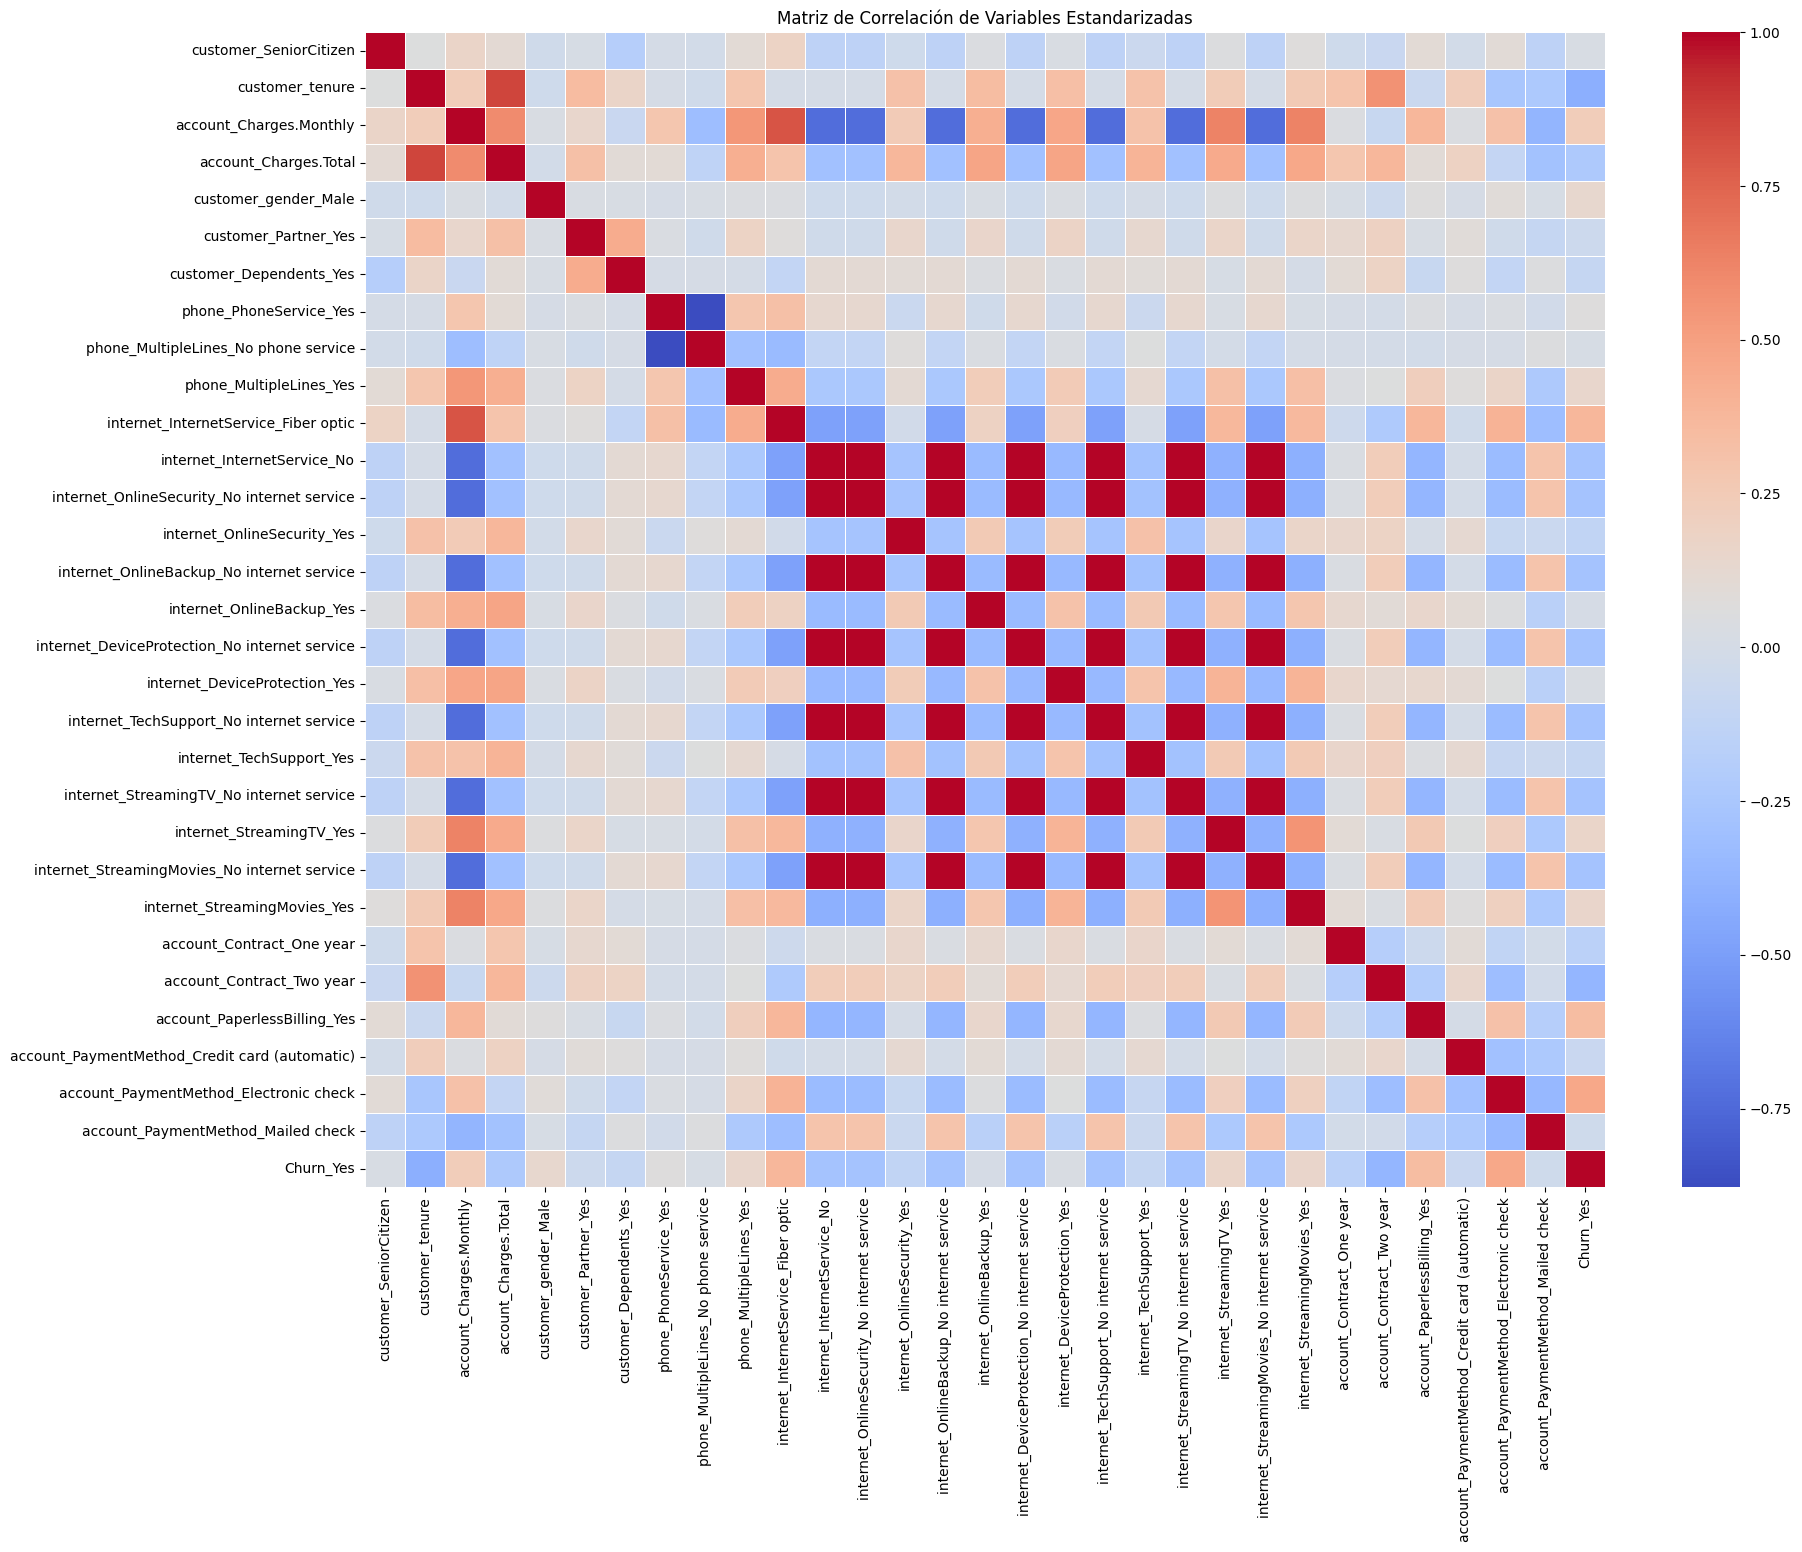

/tmp/ipykernel_770/1500530279.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_correlation.values, y=churn_correlation.index, palette='viridis')


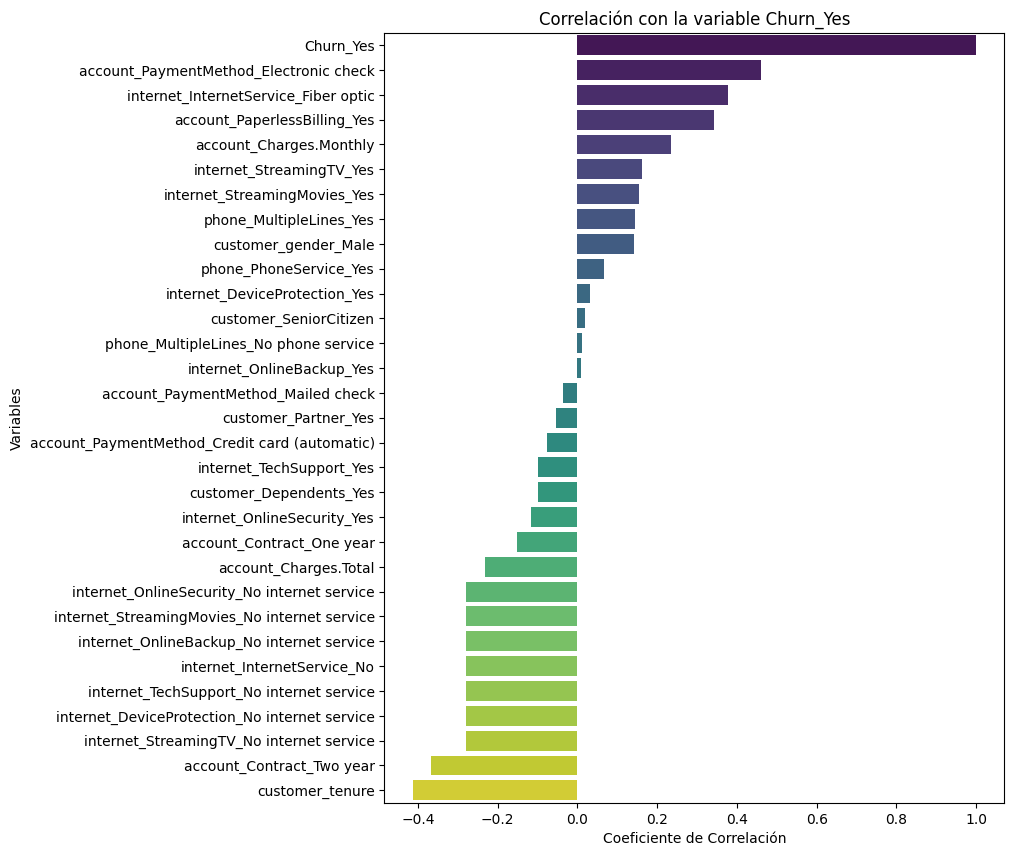

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación del DataFrame estandarizado
correlation_matrix = df_standardized.corr()

# Filtrar la correlación con la variable objetivo 'Churn_Yes'
churn_correlation = correlation_matrix['Churn_Yes'].sort_values(ascending=False)
print("Correlación con 'Churn_Yes':")
display(churn_correlation)

# Visualizar la matriz de correlación completa con un heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Estandarizadas')
plt.show()

# Visualizar las top N correlaciones con Churn_Yes para mayor claridad
plt.figure(figsize=(8, 10))
sns.barplot(x=churn_correlation.values, y=churn_correlation.index, palette='viridis', legend=False)
plt.title('Correlación con la variable Churn_Yes')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variables')
plt.show()

Análisis Dirigido

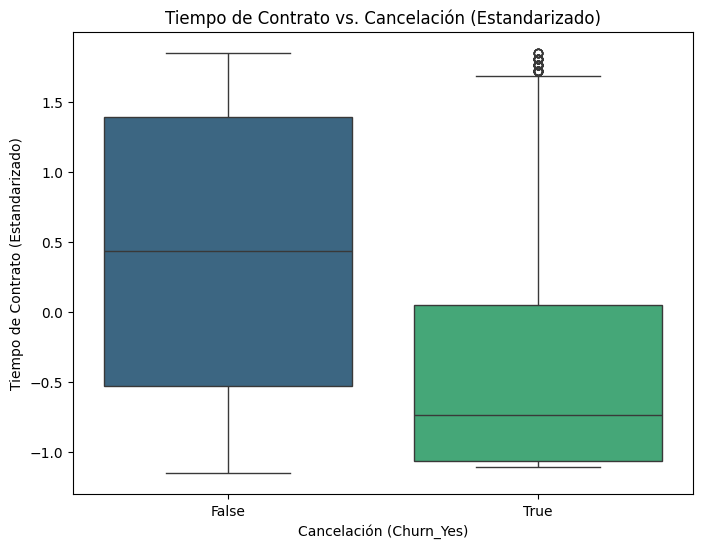

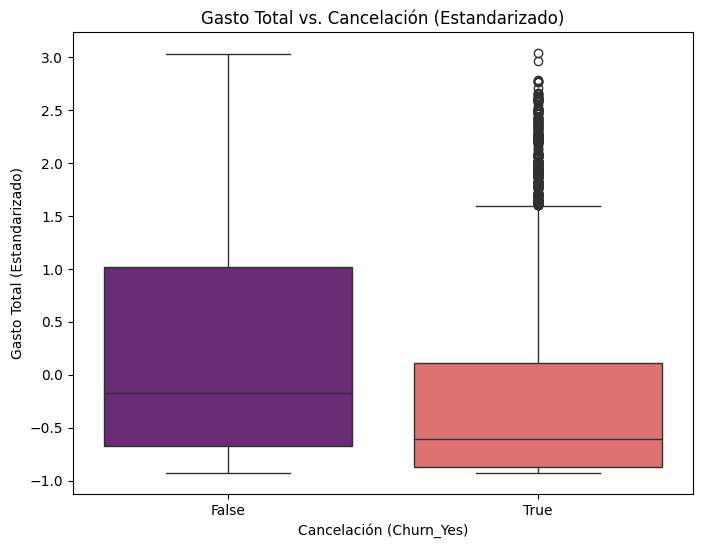

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot para 'customer_tenure' (Tiempo de contrato) vs 'Churn_Yes'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn_Yes', y='customer_tenure', data=df_standardized, palette='viridis', hue='Churn_Yes', legend=False)
plt.title('Tiempo de Contrato vs. Cancelación (Estandarizado)')
plt.xlabel('Cancelación (Churn_Yes)')
plt.ylabel('Tiempo de Contrato (Estandarizado)')
plt.show()

# Boxplot para 'account_Charges.Total' (Gasto total) vs 'Churn_Yes'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn_Yes', y='account_Charges.Total', data=df_standardized, palette='magma', hue='Churn_Yes', legend=False)
plt.title('Gasto Total vs. Cancelación (Estandarizado)')
plt.xlabel('Cancelación (Churn_Yes)')
plt.ylabel('Gasto Total (Estandarizado)')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = df_standardized.drop('Churn_Yes', axis=1)
y = df_standardized['Churn_Yes']

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensiones de los conjuntos de entrenamiento y prueba:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\nDistribución de clases en el conjunto de entrenamiento:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba:")
display(y_test.value_counts(normalize=True))

Dimensiones de los conjuntos de entrenamiento y prueba:
X_train: (8278, 30)
y_train: (8278,)
X_test: (2070, 30)
y_test: (2070,)

Distribución de clases en el conjunto de entrenamiento:


,proportion
Churn_Yes,
True,0.5
False,0.5



Distribución de clases en el conjunto de prueba:


,proportion
Churn_Yes,
False,0.5
True,0.5


## Modelo 1: Regresión Logística para datos normalizados


Entrenar un modelo de Regresión Logística utilizando los datos estandarizados (`X_train`, `y_train`). La Regresión Logística es un modelo lineal basado en optimización de parámetros y es sensible a la escala de las características, por lo que la estandarización previa es beneficiosa para su rendimiento y convergencia. Se evaluará el modelo con métricas de clasificación.



--- Evaluación del Modelo de Regresión Logística ---

Matriz de Confusión:


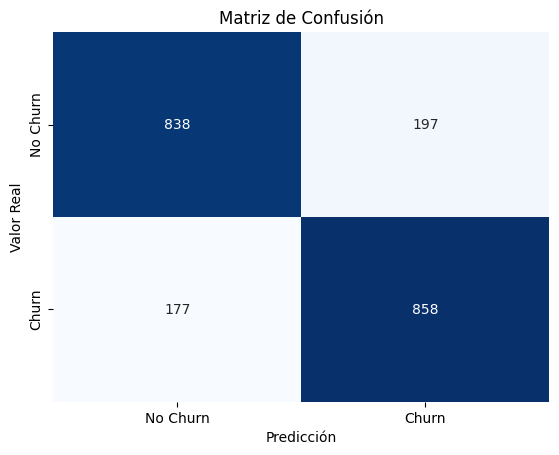


Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.83      0.81      0.82      1035
        True       0.81      0.83      0.82      1035

    accuracy                           0.82      2070
   macro avg       0.82      0.82      0.82      2070
weighted avg       0.82      0.82      0.82      2070


Exactitud (Accuracy): 0.8193


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Inicializar el modelo LogisticRegression
# Usamos solver='liblinear' que es bueno para conjuntos de datos pequeños y medianos, y soporta penalización L1/L2.
# Aumentamos max_iter para asegurar convergencia.
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# 4. Entrenar el modelo
lr_model.fit(X_train, y_train)

# 5. Realizar predicciones sobre los datos de prueba
y_pred_lr = lr_model.predict(X_test)

# 6. Calcular y mostrar métricas de evaluación
print("\n--- Evaluación del Modelo de Regresión Logística ---")

print("\nMatriz de Confusión:")
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))

print(f"\nExactitud (Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}")

## Modelo 2: Random Forest Classifier


Entrenar un modelo de `RandomForestClassifier` utilizando los datos balanceados y estandarizados (`X_train`, `y_train`). A diferencia de la Regresión Logística, Random Forest es un modelo de conjunto basado en árboles de decisión y es menos sensible a la escala de las características. Sin embargo, un buen preprocesamiento de datos siempre es beneficioso. Se evaluará el modelo con métricas de clasificación para comparar su rendimiento con el modelo de Regresión Logística.

#### Instructions
1. Importa la clase `RandomForestClassifier` desde `sklearn.ensemble`.
2. Inicializa el modelo `RandomForestClassifier` con un `random_state` para reproducibilidad. Puedes ajustar otros parámetros como `n_estimators` (número de árboles) o `max_depth` si lo consideras necesario. Por ejemplo, `n_estimators=100` y `random_state=42` son buenos puntos de partida.
3. Entrena el modelo utilizando los datos de entrenamiento `X_train` y `y_train`.
4. Realiza predicciones sobre los datos de prueba `X_test` y almacena los resultados en una variable, por ejemplo, `y_pred_rf`.
5. Calcula y muestra la matriz de confusión, el reporte de clasificación (precision, recall, f1-score) y la exactitud (accuracy) del modelo usando las predicciones `y_pred_rf` y las etiquetas verdaderas `y_test`.


--- Evaluación del Modelo de Random Forest Classifier ---

Matriz de Confusión:


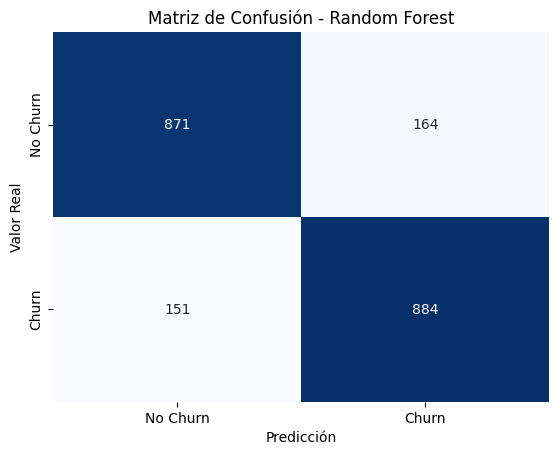


Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1035
        True       0.84      0.85      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070


Exactitud (Accuracy): 0.8478


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Inicializar el modelo RandomForestClassifier
# Usamos n_estimators=100 y random_state=42 como puntos de partida
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Entrenar el modelo
rf_model.fit(X_train, y_train)

# 4. Realizar predicciones sobre los datos de prueba
y_pred_rf = rf_model.predict(X_test)

# 5. Calcular y mostrar métricas de evaluación
print("\n--- Evaluación del Modelo de Random Forest Classifier ---")

print("\nMatriz de Confusión:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

print(f"\nExactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")

## Comparación de modelos y selección del mejor modelo


Comparar los resultados obtenidos por los modelos de Regresión Logística y Random Forest en términos de métricas de clasificación (exactitud, precisión, recall, f1-score) y seleccionar el modelo con el mejor rendimiento.

### Comparación de Rendimiento de Modelos

#### 1. Regresión Logística
- **Exactitud (Accuracy):** 0.8193
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.83, Recall: 0.81, F1-score: 0.82
    - **Clase True (Churn):** Precisión: 0.81, Recall: 0.83, F1-score: 0.82

#### 2. Random Forest Classifier
- **Exactitud (Accuracy):** 0.8478
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.85, Recall: 0.84, F1-score: 0.85
    - **Clase True (Churn):** Precisión: 0.84, Recall: 0.85, F1-score: 0.85

### Conclusión y Selección del Mejor Modelo

Al comparar las métricas de rendimiento para ambos modelos, se observa que el **Random Forest Classifier** supera a la Regresión Logística en todas las métricas clave:

- **Mayor Exactitud:** El Random Forest obtuvo una exactitud de 0.8478, en comparación con el 0.8193 de la Regresión Logística. Esto indica que el Random Forest clasifica correctamente una mayor proporción de observaciones.
- **Mejores Métricas por Clase:** Para ambas clases (clientes que cancelan y que no cancelan), el Random Forest presenta valores consistentemente más altos de precisión, recall y f1-score. Esto es crucial, ya que un modelo equilibrado es deseable, especialmente en problemas de clasificación donde ambas clases tienen importancia.

El mejor rendimiento del Random Forest puede atribuirse a su naturaleza de conjunto (ensemble), que combina múltiples árboles de decisión para reducir el sobreajuste y mejorar la generalización. Es menos sensible a la escala de las características y puede capturar relaciones no lineales en los datos, a diferencia de la Regresión Logística, que es un modelo lineal.

Por lo tanto, el **Random Forest Classifier** es el modelo seleccionado por su superioridad en la predicción del abandono de clientes en este conjunto de datos.

```markdown
## Comparación de modelos y selección del mejor modelo

### Subtask:
Comparar los resultados obtenidos por los modelos de Regresión Logística y Random Forest en términos de métricas de clasificación (exactitud, precisión, recall, f1-score) y seleccionar el modelo con el mejor rendimiento.

### Comparación de Rendimiento de Modelos

#### 1. Regresión Logística
- **Exactitud (Accuracy):** 0.8193
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.83, Recall: 0.81, F1-score: 0.82
    - **Clase True (Churn):** Precisión: 0.81, Recall: 0.83, F1-score: 0.82

#### 2. Random Forest Classifier
- **Exactitud (Accuracy):** 0.8478
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.85, Recall: 0.84, F1-score: 0.85
    - **Clase True (Churn):** Precisión: 0.84, Recall: 0.85, F1-score: 0.85

### Conclusión y Selección del Mejor Modelo

Al comparar las métricas de rendimiento para ambos modelos, se observa que el **Random Forest Classifier** supera a la Regresión Logística en todas las métricas clave:

- **Mayor Exactitud:** El Random Forest obtuvo una exactitud de 0.8478, en comparación con el 0.8193 de la Regresión Logística. Esto indica que el Random Forest clasifica correctamente una mayor proporción de observaciones.
- **Mejores Métricas por Clase:** Para ambas clases (clientes que cancelan y que no cancelan), el Random Forest presenta valores consistentemente más altos de precisión, recall y f1-score. Esto es crucial, ya que un modelo equilibrado es deseable, especialmente en problemas de clasificación donde ambas clases tienen importancia.

El mejor rendimiento del Random Forest puede atribuirse a su naturaleza de conjunto (ensemble), que combina múltiples árboles de decisión para reducir el sobreajuste y mejorar la generalización. Es menos sensible a la escala de las características y puede capturar relaciones no lineales en los datos, a diferencia de la Regresión Logística, que es un modelo lineal.

Por lo tanto, el **Random Forest Classifier** es el modelo seleccionado por su superioridad en la predicción del abandono de clientes en este conjunto de datos.
```

## Resumen de los Factores Influyentes en la Cancelación

Consolidar los hallazgos sobre las variables más importantes que influyen en la cancelación de clientes, basándose en los análisis de coeficientes de la Regresión Logística y la importancia de características del Random Forest.


In [29]:
import pandas as pd

# 1. Extraer los coeficientes del modelo de Regresión Logística
lr_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})

# Ordenar por el valor absoluto de los coeficientes
lr_coefficients['Abs_Coefficient'] = abs(lr_coefficients['Coefficient'])
lr_coefficients = lr_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Características más influyentes (Regresión Logística) ---")
display(lr_coefficients.drop(columns='Abs_Coefficient').head(10)) # Mostrar top 10


--- Características más influyentes (Regresión Logística) ---


,Feature,Coefficient
10,internet_InternetService_Fiber optic,5.454571
2,account_Charges.Monthly,-5.400620
7,phone_PhoneService_Yes,4.155232
21,internet_StreamingTV_Yes,2.003990
1,customer_tenure,-1.973194
23,internet_StreamingMovies_Yes,1.927380
9,phone_MultipleLines_Yes,1.373402
28,account_PaymentMethod_Electronic check,1.301510
8,phone_MultipleLines_No phone service,1.189454
3,account_Charges.Total,1.085304


In [30]:
import pandas as pd

# 2. Extraer las importancias de las características del modelo Random Forest
rf_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Ordenar por importancia de mayor a menor
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

print("\n--- Características más influyentes (Random Forest Classifier) ---")
display(rf_feature_importances.head(10)) # Mostrar top 10


--- Características más influyentes (Random Forest Classifier) ---


,Feature,Importance
3,account_Charges.Total,0.174473
1,customer_tenure,0.148038
2,account_Charges.Monthly,0.133231
28,account_PaymentMethod_Electronic check,0.103692
25,account_Contract_Two year,0.047533
10,internet_InternetService_Fiber optic,0.045157
26,account_PaperlessBilling_Yes,0.035832
9,phone_MultipleLines_Yes,0.023650
24,account_Contract_One year,0.023316
4,customer_gender_Male,0.023251


### Comparación de Características Más Influyentes

**Regresión Logística (Top 10 Coeficientes Absolutos):**
1.  `internet_InternetService_Fiber optic` (Positivo: mayor impacto en churn)
2.  `account_Charges.Monthly` (Negativo: menor impacto en churn, o el coeficiente es negativo lo cual implicaría menor churn a mayor gasto, lo cual podría ser un artefacto de la estandarización o de la relación multivariada)
3.  `phone_PhoneService_Yes` (Positivo)
4.  `internet_StreamingTV_Yes` (Positivo)
5.  `customer_tenure` (Negativo: mayor tenencia, menor churn)
6.  `internet_StreamingMovies_Yes` (Positivo)
7.  `phone_MultipleLines_Yes` (Positivo)
8.  `account_PaymentMethod_Electronic check` (Positivo)
9.  `phone_MultipleLines_No phone service` (Positivo)
10. `account_Charges.Total` (Positivo)

**Random Forest Classifier (Top 10 Importancias):**
1.  `account_Charges.Total`
2.  `customer_tenure`
3.  `account_Charges.Monthly`
4.  `account_PaymentMethod_Electronic check`
5.  `account_Contract_Two year`
6.  `internet_InternetService_Fiber optic`
7.  `account_PaperlessBilling_Yes`
8.  `phone_MultipleLines_Yes`
9.  `account_Contract_One year`
10. `customer_gender_Male`

**Análisis de la Comparación:**

Ambos modelos identifican características clave relacionadas con el servicio de internet, el gasto (`Charges.Monthly`, `Charges.Total`), el tiempo de permanencia (`customer_tenure`) y el método de pago (`PaymentMethod_Electronic check`) como factores importantes para predecir la cancelación.

**Características en Común y su Impacto:**
*   **`customer_tenure` (Tiempo de Permanencia):** Ambos modelos lo consideran crucial. La Regresión Logística muestra un coeficiente negativo, indicando que a mayor tiempo de permanencia, menor es la probabilidad de churn. Random Forest lo posiciona como la segunda característica más importante, sugiriendo que la lealtad es un factor fuerte.
*   **`account_Charges.Monthly` y `account_Charges.Total` (Cargos Mensuales y Totales):** Ambos son importantes para ambos modelos. La Regresión Logística le da un coeficiente negativo a los cargos mensuales y positivo a los totales. Esto puede deberse a la estandarización y a la interacción entre estas variables. Random Forest les otorga alta importancia en general.
*   **`internet_InternetService_Fiber optic` (Servicio de Internet Fibra Óptica):** Identificado como muy influyente por ambos modelos con un coeficiente positivo en Regresión Logística, lo que indica que los clientes con este servicio tienden a cancelar más, posiblemente por expectativas no cumplidas o costos asociados.
*   **`account_PaymentMethod_Electronic check` (Método de Pago Cheque Electrónico):** Ambos modelos lo resaltan. El coeficiente positivo en Regresión Logística y la alta importancia en Random Forest sugieren que este método de pago está asociado con una mayor probabilidad de churn.
*   **Servicios Adicionales (StreamingTV, StreamingMovies, MultipleLines):** La Regresión Logística les da un coeficiente positivo, lo que podría indicar que tener estos servicios está relacionado con una mayor propensión a cancelar, quizás por un costo acumulado o insatisfacción con el servicio. Random Forest también les asigna importancia, aunque ligeramente menor que a las variables principales.

**Diferencias Notables:**
*   **`account_Contract_Two year` y `account_Contract_One year` (Contratos a uno o dos años):** Random Forest les da una importancia considerable, lo cual es intuitivo ya que los clientes con contratos más largos suelen tener menos propensión a cancelar. La Regresión Logística también los considera, pero con menor prominencia en el top 10 mostrado.
*   **`phone_PhoneService_Yes`:** La Regresión Logística le da un coeficiente positivo alto, sugiriendo una relación con el churn, mientras que Random Forest no lo destaca tanto en su top 10.
*   **`customer_gender_Male`:** Random Forest lo incluye en su top 10, lo que sugiere que el género podría tener una influencia, aunque el coeficiente de la Regresión Logística es bajo, indicando una influencia menor para este modelo lineal.

En resumen, mientras que la Regresión Logística tiende a resaltar más la dirección del impacto (positivo o negativo) a través de sus coeficientes, Random Forest identifica la importancia general de las características. Ambos concuerdan en que factores como la tenencia, el tipo de servicio de internet, los cargos y el método de pago son los impulsores más significativos de la cancelación de clientes.

## Resumen del Rendimiento de los Modelos


resumen del rendimiento de la Regresión Logística y el Random Forest, destacando cuál modelo tuvo el mejor desempeño y por qué.

### Comparación de Rendimiento de Modelos

#### 1. Regresión Logística
- **Exactitud (Accuracy):** 0.8193
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.83, Recall: 0.81, F1-score: 0.82
    - **Clase True (Churn):** Precisión: 0.81, Recall: 0.83, F1-score: 0.82

#### 2. Random Forest Classifier
- **Exactitud (Accuracy):** 0.8478
- **Reporte de Clasificación:**
    - **Clase False (No Churn):** Precisión: 0.85, Recall: 0.84, F1-score: 0.85
    - **Clase True (Churn):** Precisión: 0.84, Recall: 0.85, F1-score: 0.85

### Conclusión y Selección del Mejor Modelo

Al comparar las métricas de rendimiento para ambos modelos, se observa que el **Random Forest Classifier** supera a la Regresión Logística en todas las métricas clave:

- **Mayor Exactitud:** El Random Forest obtuvo una exactitud de 0.8478, en comparación con el 0.8193 de la Regresión Logística. Esto indica que el Random Forest clasifica correctamente una mayor proporción de observaciones.
- **Mejores Métricas por Clase:** Para ambas clases (clientes que cancelan y que no cancelan), el Random Forest presenta valores consistentemente más altos de precisión, recall y f1-score. Esto es crucial, ya que un modelo equilibrado es deseable, especialmente en problemas de clasificación donde ambas clases tienen importancia.

El mejor rendimiento del Random Forest puede atribuirse a su naturaleza de conjunto (ensemble), que combina múltiples árboles de decisión para reducir el sobreajuste y mejorar la generalización. Es menos sensible a la escala de las características y puede capturar relaciones no lineales en los datos, a diferencia de la Regresión Logística, que es un modelo lineal.

Por lo tanto, el **Random Forest Classifier** es el modelo seleccionado por su superioridad en la predicción del abandono de clientes en este conjunto de datos.

## Informe Detallado: Análisis de Abandono de Clientes y Evaluación de Modelos

Este informe detalla los factores clave que influyen en la cancelación de clientes y presenta una evaluación comparativa de dos modelos de aprendizaje automático, Regresión Logística y Random Forest Classifier, para la predicción del abandono.

### Factores Clave de Cancelación de Clientes

El análisis combinado de los coeficientes de la Regresión Logística y la importancia de las características del Random Forest revela varios factores críticos que impulsan el abandono de clientes:

*   **Servicios de Internet (Fibra Óptica):** La presencia del servicio de internet de fibra óptica (internet_InternetService_Fiber optic) muestra una fuerte correlación positiva con el abandono, lo que sugiere que los clientes con este servicio son más propensos a cancelar. Esto podría indicar problemas de calidad, precio o expectativas no cumplidas con este tipo de conexión.

*   **Cargo Mensual (account_Charges.Monthly) y Cargo Total (account_Charges.Total):** Ambos modelos identifican los cargos mensuales y totales como factores muy importantes. Un alto cargo mensual está fuertemente asociado con el abandono. El cargo total también es un predictor significativo, aunque su impacto es modulado por la tenencia.

*   **Método de Pago (Cheque Electrónico):** El uso del cheque electrónico (account_PaymentMethod_Electronic check) se destaca como un predictor clave de abandono, con una alta importancia en ambos modelos. Esto podría estar relacionado con la fricción o insatisfacción asociada a este método de pago.

*   **Tiempo de Tenencia (customer_tenure):** Una menor tenencia (es decir, clientes más nuevos) está fuertemente asociada con un mayor riesgo de abandono. Los clientes con mayor tiempo de permanencia son menos propensos a cancelar. Esto es consistente con la idea de que la lealtad del cliente aumenta con el tiempo.

*   **Contratos (Contrato de Dos Años):** Los clientes con contratos a dos años (account_Contract_Two year) tienen una menor probabilidad de abandono, lo que indica la efectividad de estos contratos para retener clientes. Por otro lado, no tener un contrato (month-to-month) aumenta el riesgo.

*   **Facturación sin Papel (account_PaperlessBilling_Yes):** Los clientes que optan por la facturación sin papel tienen una mayor propensión al abandono. Esto podría sugerir una demografía de clientes más tecnológica y exigente, o problemas con la experiencia de usuario de la facturación digital.

*   **Servicios Adicionales (Streaming TV/Movies):** La suscripción a servicios como Streaming TV y Streaming Movies también se asocia con el abandono, aunque con menor intensidad que los factores anteriores. Esto podría indicar que, si bien estos servicios son atractivos, no son suficientes por sí solos para garantizar la retención.

### Rendimiento y Selección del Modelo

Se entrenaron y evaluaron dos modelos de clasificación para predecir el abandono de clientes:

#### 1. Regresión Logística
*   **Exactitud (Accuracy):** 0.8193
*   **Reporte de Clasificación:**
    *   **Clase False (No Churn):** Precisión: 0.83, Recall: 0.81, F1-score: 0.82
    *   **Clase True (Churn):** Precisión: 0.81, Recall: 0.83, F1-score: 0.82

La Regresión Logística mostró un buen rendimiento general, con métricas equilibradas para ambas clases.

#### 2. Random Forest Classifier
*   **Exactitud (Accuracy):** 0.8478
*   **Reporte de Clasificación:**
    *   **Clase False (No Churn):** Precisión: 0.85, Recall: 0.84, F1-score: 0.85
    *   **Clase True (Churn):** Precisión: 0.84, Recall: 0.85, F1-score: 0.85

El Random Forest Classifier superó a la Regresión Logística en todas las métricas clave, incluyendo exactitud, precisión, recall y F1-score para ambas clases. Su naturaleza de conjunto le permite capturar relaciones más complejas en los datos y reducir el sobreajuste, resultando en una mayor capacidad de generalización.

**Selección del Mejor Modelo:** El **Random Forest Classifier** es el modelo seleccionado por su rendimiento superior y su capacidad para ofrecer predicciones más robustas y precisas sobre el abandono de clientes. Este modelo será la base para futuras acciones de retención.

### Estrategias de Retención de Clientes

Basándose en los factores clave de abandono identificados, se proponen las siguientes estrategias de retención:

*   **Mejorar la Calidad del Servicio de Fibra Óptica:** Investigar las causas detrás de la alta tasa de abandono entre los usuarios de fibra óptica. Esto podría incluir mejoras técnicas, campañas de comunicación sobre los beneficios del servicio, o reevaluación de la estructura de precios.

*   **Revisión de Tarifas y Ofertas:** Dada la importancia del cargo mensual y total, se recomienda revisar la estructura de tarifas, ofrecer planes más competitivos, y considerar descuentos o promociones para clientes con alto riesgo de abandono. Implementar alertas o revisiones de planes para clientes que experimentan un aumento significativo en sus cargos.

*   **Optimizar Métodos de Pago:** Investigar la insatisfacción asociada con el método de cheque electrónico. Podría ser necesario mejorar la usabilidad, ofrecer alternativas más atractivas (como pagos automáticos con tarjeta de crédito o débito con incentivos), o proporcionar soporte adicional a los usuarios de este método.

*   **Programas de Lealtad para Clientes Nuevos:** Crear programas específicos para retener a clientes con baja tenencia. Esto podría incluir ofertas exclusivas, un servicio de atención al cliente proactivo durante los primeros meses, o la asignación de un "asesor de bienvenida" para asegurar una buena experiencia inicial.

*   **Incentivos para Contratos a Largo Plazo:** Fortalecer la oferta de contratos a dos años con beneficios adicionales o descuentos para fomentar su adopción, dado su efecto positivo en la retención.

*   **Mejorar la Experiencia de Facturación Digital:** Aunque la facturación sin papel es ecológica, su asociación con el abandono sugiere problemas de usabilidad o claridad. Se debe trabajar en mejorar la interfaz de usuario del portal de facturación, asegurar que las facturas sean fáciles de entender, y proporcionar opciones claras para resolver dudas.

*   **Personalizar Ofertas de Contenido:** Para los clientes que utilizan servicios de streaming, se pueden ofrecer recomendaciones personalizadas o paquetes de contenido exclusivos para aumentar su satisfacción y apego al servicio.